<a href="https://colab.research.google.com/github/ayushpaliwal1920/NLP/blob/main/SentimentAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.stem.porter import PorterStemmer
nltk.download('stopwords')
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import pickle
import re

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


EDA :

In [5]:
data = pd.read_csv('/content/amazon_alexa.tsv' , delimiter= '\t' , quoting = 3)
print(f'Dataset shape : {data.shape}')

Dataset shape : (3150, 5)


In [6]:
data.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"""Sometimes while playing a game, you can answe...",1
3,5,31-Jul-18,Charcoal Fabric,"""I have had a lot of fun with this thing. My 4...",1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [7]:
# column names :

print(f"Feature names : {data.columns.values}")

Feature names : ['rating' 'date' 'variation' 'verified_reviews' 'feedback']


In [8]:
# null values ?

data.isnull().sum()

,0
rating,0
date,0
variation,0
verified_reviews,1
feedback,0


In [9]:
#  gettting the record where verified_reviews is null :

data[data['verified_reviews'].isna() == True]

,rating,date,variation,verified_reviews,feedback
473,2,29-Jun-18,White,NaN,0


In [10]:
# drop null value :

data.dropna(inplace = True)

In [11]:
# shape :

print(f'Dataset shape : {data.shape}')


Dataset shape : (3149, 5)


In [12]:
# Adding length column :

data['length'] = data['verified_reviews'].apply(len)

In [13]:
data.head()

,rating,date,variation,verified_reviews,feedback,length
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1,13
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1,9
2,4,31-Jul-18,Walnut Finish,"""Sometimes while playing a game, you can answe...",1,197
3,5,31-Jul-18,Charcoal Fabric,"""I have had a lot of fun with this thing. My 4...",1,174
4,5,31-Jul-18,Charcoal Fabric,Music,1,5


In [14]:
#  datatypes :

data.dtypes

,0
rating,int64
date,object
variation,object
verified_reviews,object
feedback,int64
length,int64


Analyzing Rating column :

In [15]:
# Rating : Positive Reviews(5,4,3) is 91% and negative reviews 9% means data is imbalanced

print(f'Rating value count : \n {data['rating'].value_counts()}\n')

print(f"Rating value count - percentage distribution : \n{round(data['rating'].value_counts()/data.shape[0]*100,2)}")

Rating value count : 
 rating
5    2286
4     455
1     161
3     152
2      95
Name: count, dtype: int64

Rating value count - percentage distribution : 
rating
5    72.59
4    14.45
1     5.11
3     4.83
2     3.02
Name: count, dtype: float64


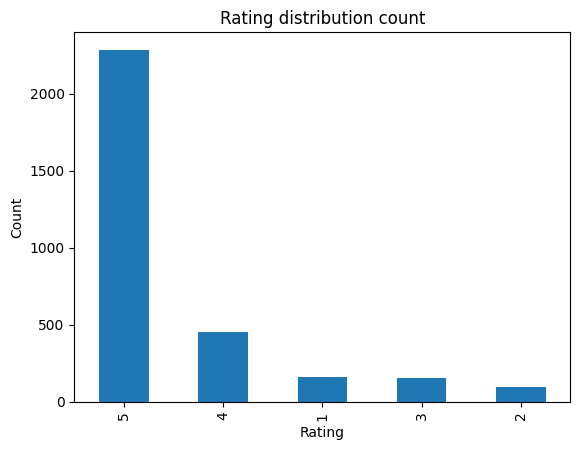

In [16]:
# Plotting :

data['rating'].value_counts().plot.bar()
plt.title('Rating distribution count')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

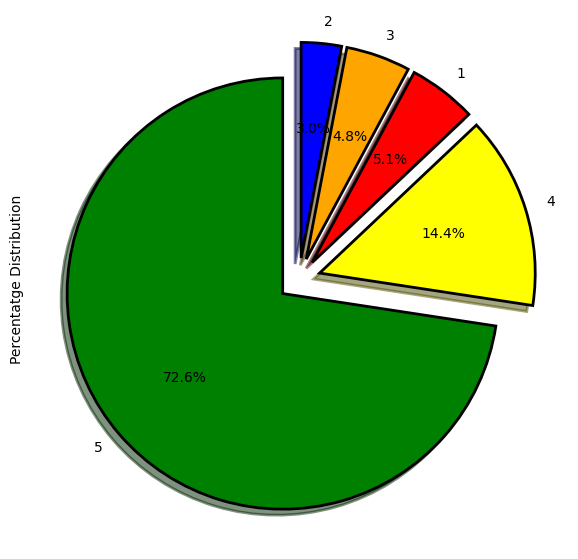

In [17]:
# Pie chart :

fig = plt.figure(figsize = (7,7))

colors = {'red' , 'green' , 'blue' , 'orange' , 'yellow'}

wp = {'linewidth':2 , "edgecolor" : 'black'}

tags = data['rating'].value_counts()/data.shape[0]

explode =(0.1,0.1,0.1,0.1,0.1)

tags.plot(kind = 'pie' , autopct = "%1.1f%%" , shadow = True , colors = colors , startangle = 90 , wedgeprops= wp , explode = explode , label = "Percentatge Distribution" )

from io import BytesIO

Analyzing FeedBack column :

In [18]:
# Feedback : checking  Imbalance

print(f'Feedback value count : \n {data['feedback'].value_counts()}\n\n')

print(f"Feedback value count - percentage distribution : \n{round(data['feedback'].value_counts()/data.shape[0]*100,2)}")

Feedback value count : 
 feedback
1    2893
0     256
Name: count, dtype: int64


Feedback value count - percentage distribution : 
feedback
1    91.87
0     8.13
Name: count, dtype: float64


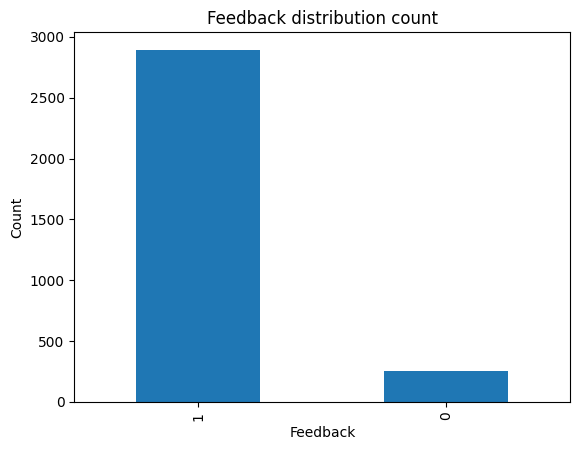

In [19]:
# Plotting :

data['feedback'].value_counts().plot.bar()
plt.title('Feedback distribution count')
plt.xlabel('Feedback')
plt.ylabel('Count')
plt.show()

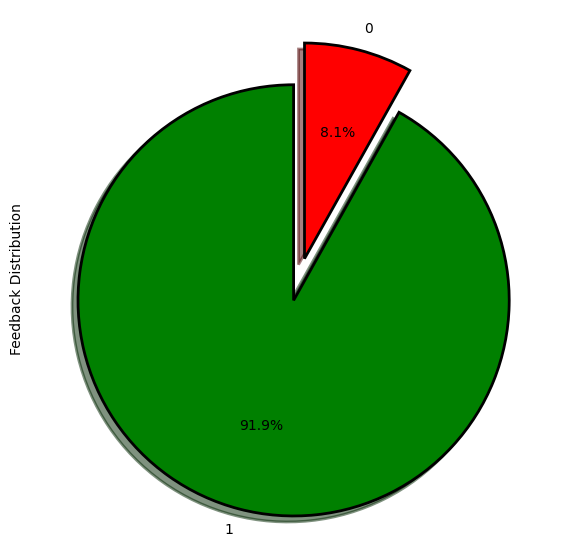

In [20]:
fig = plt.figure(figsize = (7,7))

colors = {'red' , 'green' }

wp = {'linewidth':2 , "edgecolor" : 'black'}

tags = data['feedback'].value_counts()/data.shape[0]

explode =(0.1,0.1)

tags.plot(kind = 'pie' , autopct = "%1.1f%%" , shadow = True , colors = colors , startangle = 90 , wedgeprops= wp , explode = explode , label = "Feedback Distribution" )

from io import BytesIO

In [21]:
# feedback = 0

data[data['feedback'] == 0]['rating'].value_counts()

,count
rating,
1,161
2,95


In [22]:
# feedback = 1

data[data['feedback'] == 1]['rating'].value_counts()

,count
rating,
5,2286
4,455
3,152


Analyzing variation column :

In [23]:
# Variation : checking  Imbalance

print(f'Variation value count : \n {data['variation'].value_counts()}\n\n')

print(f"Variation value count - percentage distribution : \n{round(data['variation'].value_counts()/data.shape[0]*100,2)}")

Variation value count : 
 variation
Black  Dot                      516
Charcoal Fabric                 430
Configuration: Fire TV Stick    350
Black  Plus                     270
Black  Show                     265
Black                           261
Black  Spot                     241
White  Dot                      184
Heather Gray Fabric             157
White  Spot                     109
Sandstone Fabric                 90
White                            90
White  Show                      85
White  Plus                      78
Oak Finish                       14
Walnut Finish                     9
Name: count, dtype: int64


Variation value count - percentage distribution : 
variation
Black  Dot                      16.39
Charcoal Fabric                 13.66
Configuration: Fire TV Stick    11.11
Black  Plus                      8.57
Black  Show                      8.42
Black                            8.29
Black  Spot                      7.65
White  Dot                       

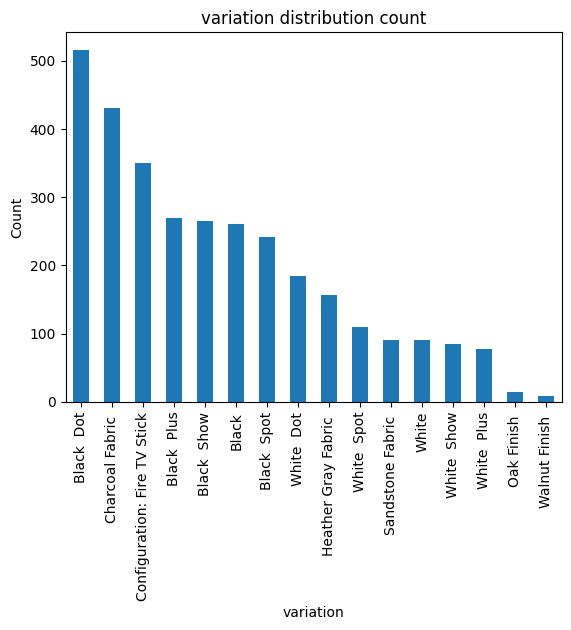

In [24]:
# Plotting :

data['variation'].value_counts().plot.bar()
plt.title('variation distribution count')
plt.xlabel('variation')
plt.ylabel('Count')
plt.show()

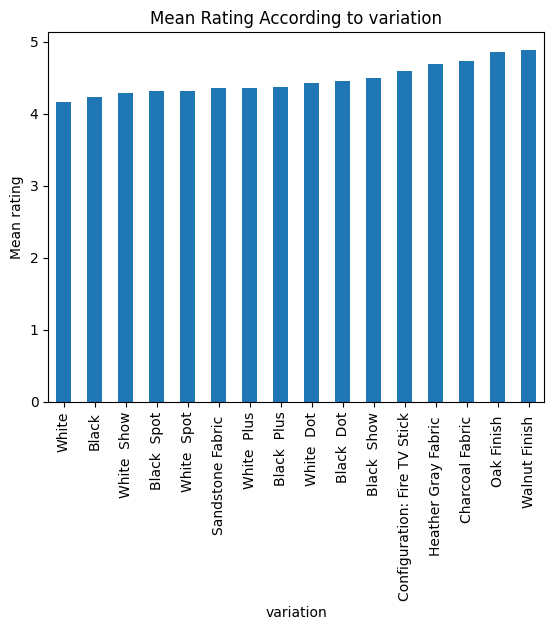

In [25]:
data.groupby('variation')['rating'].mean().sort_values().plot.bar()
plt.title('Mean Rating According to variation')
plt.xlabel('variation')
plt.ylabel('Mean rating')
plt.show()

Analyze Verified Reviews :

In [26]:
data['length'].describe()

,length
count,3149.000000
mean,132.714513
std,182.541531
min,1.000000
25%,30.000000
50%,74.000000
75%,166.000000
max,2853.000000


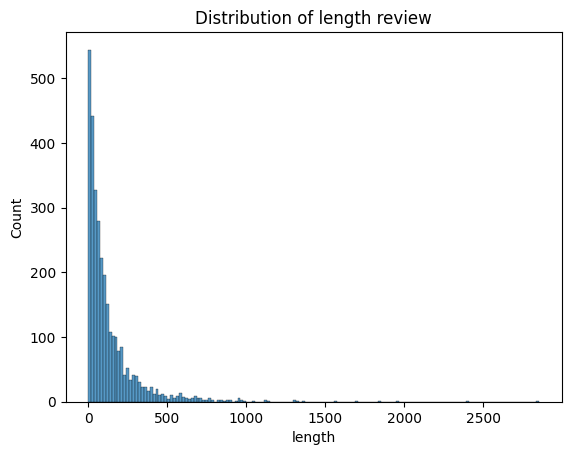

In [27]:
# length analysis : full dataset

sns.histplot(data['length']).set(title = 'Distribution of length review')
plt.show()

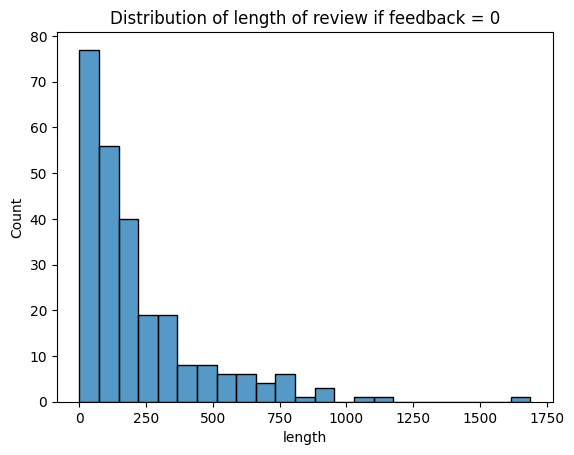

In [28]:
# length analysis when feedback is 0 :

sns.histplot(data[data['feedback'] == 0]['length']).set(title = "Distribution of length of review if feedback = 0")
plt.show()

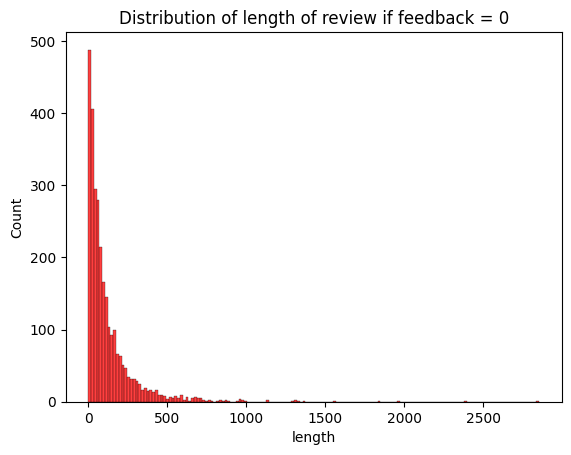

In [29]:
# length analysis when feedback is 1 :

sns.histplot(data[data['feedback'] == 1]['length'] , color = 'red').set(title = "Distribution of length of review if feedback = 0")
plt.show()

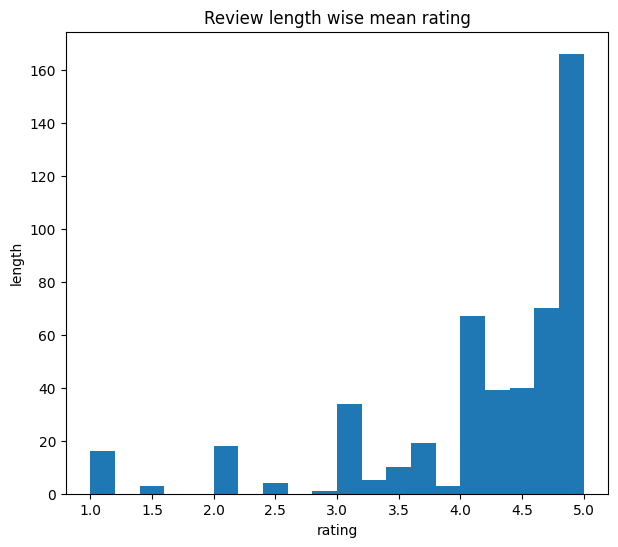

In [30]:
# Length wise mean rating :

data.groupby('length')['rating'].mean().plot.hist(bins = 20 , figsize = (7,6))
plt.title("Review length wise mean rating")
plt.xlabel('rating')
plt.ylabel('length')
plt.show()

In [31]:
# Vectorization :

cv = CountVectorizer(stop_words='english')
words = cv.fit_transform(data.verified_reviews)

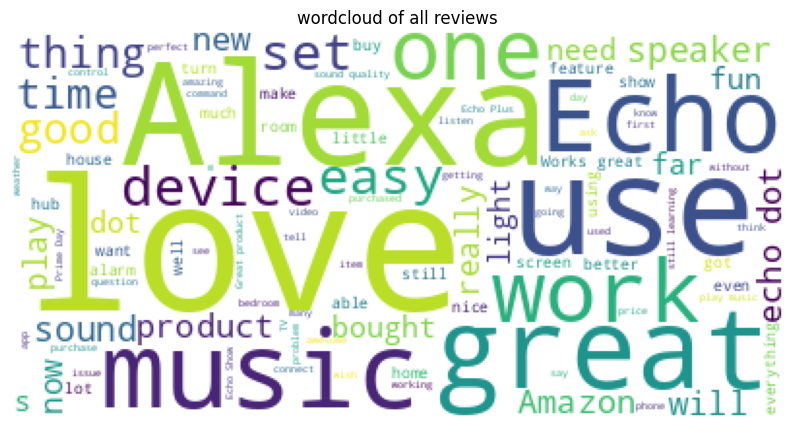

In [32]:
# combine all reviews

reviews = " ".join([review for review in data['verified_reviews']])

# Initialize wordcloud object

wc = WordCloud(background_color='white' , max_words = 100)

# generate and plot wordcloud

plt.figure(figsize= (10,10))
plt.imshow(wc.generate(reviews))
plt.title('wordcloud of all reviews')
plt.axis('off')
plt.show()

In [33]:
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize , sent_tokenize

def tokenize(text):
    if not isinstance(text, str):
        return text
    return word_tokenize(text)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [34]:
# combine all reviews for each feedback category and splitting them into individual words

neg_reviews = " ".join([review for review in data[data['feedback'] == 0]['verified_reviews']])
neg_reviews = neg_reviews.lower().split()

pos_reviews = " ".join([review for review in data[data['feedback'] == 1]['verified_reviews']])
pos_reviews = pos_reviews.lower().split()

# finding words from reviews which are present in that feedback category

unique_negative = [x for x in neg_reviews if x not in pos_reviews]
unique_negative = " ".join(unique_negative)

unique_positive = [x for x in pos_reviews if x not in neg_reviews]
unique_positive = " ".join(unique_positive)



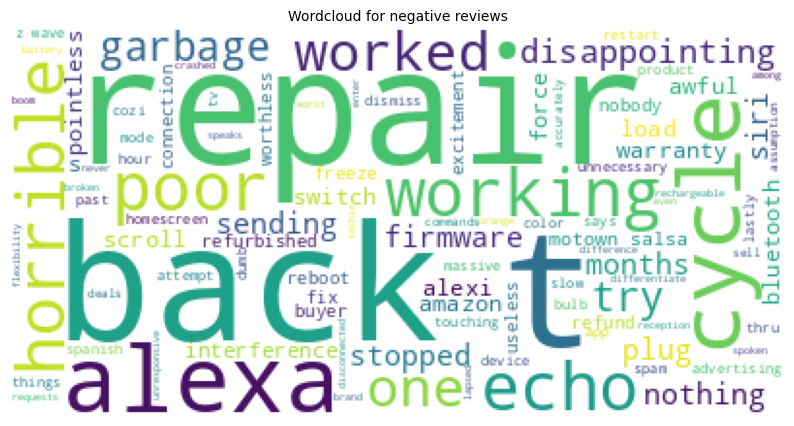

In [35]:
wc = WordCloud(background_color = 'white' , max_words = 100)

# Generate and plot wordcloud

plt.figure(figsize = (10,10))
plt.imshow(wc.generate(unique_negative))
plt.title("Wordcloud for negative reviews",fontsize = 10)
plt.axis('off')
plt.show()

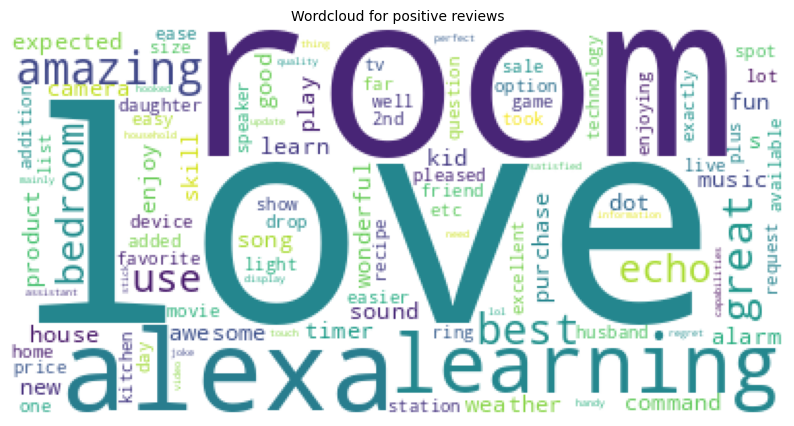

In [36]:
wc = WordCloud(background_color = 'white' , max_words = 100)

# Generate and plot wordcloud

plt.figure(figsize = (10,10))
plt.imshow(wc.generate(unique_positive))
plt.title("Wordcloud for positive reviews",fontsize = 10)
plt.axis('off')
plt.show()

# Preprocessing and Model Training

In [37]:
# Replace any non alphabet character with a space
# cover to lowercase and split into words
# iterate over the individual words and if it not a stoopword then add the stemmed form of the word to the corpus

corpus = []

stemmer = PorterStemmer()

for i in range(0 , data.shape[0]):
   review = re.sub('[^a-zA-Z]' ,' ', data.iloc[i]['verified_reviews'])
   review = review.lower().split()
   review = [stemmer.stem(word) for word in  review if not word in STOPWORDS]
   review = ' '.join(review)
   corpus.append(review)


In [38]:
# bag of words

cv = CountVectorizer(ngram_range=(1,2),max_features=2500)

# storing independent and dependent variables

x = cv.fit_transform(corpus).toarray()
y = data['feedback'].values

In [39]:
print(f'X shape : {x.shape}')
print(f'y shape : {y.shape}')

X shape : (3149, 2500)
y shape : (3149,)


In [40]:
x_train , x_test , y_train , y_test= train_test_split(x,y, test_size = 0.3 , random_state=15)

In [41]:
scaler = MinMaxScaler()

x_train_scl = scaler.fit_transform(x_train)
x_test_scl = scaler.transform(x_test)

In [42]:
# Random forest

model_rf = RandomForestClassifier()
model_rf.fit(x_train_scl , y_train)

RandomForestClassifier()

In [43]:
# Accuracy of model on training and testing data:

print(f'Training Accuracy :' , model_rf.score(x_train_scl,y_train))
print(f'Test Accuracy :' , model_rf.score(x_test_scl,y_test))


Training Accuracy : 0.9936479128856625
Test Accuracy : 0.9470899470899471


In [44]:
# Confusion matrix

cm = confusion_matrix(y_test , model_rf.predict(x_test_scl) )

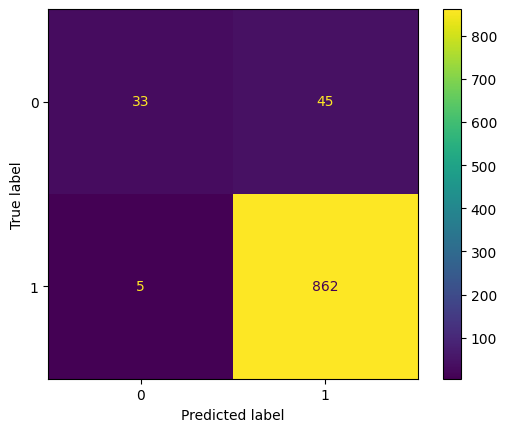

In [45]:
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm , display_labels = model_rf.classes_)
cm_display.plot()
plt.show()

K fold cross validataion :


In [46]:
accuracies = cross_val_score(estimator = model_rf , X = x_train_scl , y = y_train , cv = 10)

print('Accuracy :', accuracies.mean())
print('Standard Values :' , accuracies.std())

Accuracy : 0.9314911559029205
Standard Values : 0.01022536422329692


Applying Grid search to get the optimal parameters on random forest model.

In [47]:
params = {
    'bootstrap': [True],
    'max_depth': [80,100],
    'min_samples_split':[8,12],
    "n_estimators":[100,300]
}

In [48]:
cv_object = StratifiedKFold(n_splits = 2)

gridSearch = GridSearchCV(estimator = model_rf , param_grid = params , cv = cv_object , verbose = 0 , return_train_score = True)
gridSearch.fit(x_train_scl , y_train.ravel())

GridSearchCV(cv=StratifiedKFold(n_splits=2, random_state=None, shuffle=False),
             estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True], 'max_depth': [80, 100],
                         'min_samples_split': [8, 12],
                         'n_estimators': [100, 300]},
             return_train_score=True)

In [49]:
# Getting best parameter for the gridSearch

print(f'Best parameters combination :{format(gridSearch.best_params_)}')

Best parameters combination :{'bootstrap': True, 'max_depth': 100, 'min_samples_split': 12, 'n_estimators': 100}


In [50]:
print(f'Cross validation mean accuracy on train set : {format(gridSearch.cv_results_['mean_train_score'].mean()*100)}')
print(f'Cross validation mean accuracy on test set : {format(gridSearch.cv_results_['mean_test_score'].mean()*100)}')

Cross validation mean accuracy on train set : 96.80127041742286
Cross validation mean accuracy on test set : 92.19600725952813


XG Boost :

In [51]:
model_xgb = XGBClassifier()
model_xgb.fit(x_train_scl , y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [52]:
print(f'Accuracy on training data : {model_xgb.score(x_train_scl , y_train)}')
print(f'Accuracy on testing data : {model_xgb.score(x_test_scl , y_test)}')

Accuracy on training data : 0.9718693284936479
Accuracy on testing data : 0.9386243386243386
